#   CODEALPHA DATA SCIENCE INTERNSHIP
#   Task 2: Exploratory Data Analysis (EDA)
#   Task 3: Data Visualization
#   Task 4: Sentiment Analysis
#   Dataset: Twitter Data
#   Name: Alqama Najam
#   St ID: CA/SE3/16568

In [2]:
!pip install textblob

  Using cached textblob-0.20.0-py3-none-any.whl.metadata (4.0 kB)
Using cached textblob-0.20.0-py3-none-any.whl (624 kB)


In [40]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from textblob import TextBlob
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [14]:
#LOAD DATASET
import pandas as pd
print("\n" + "="*60)
print("  LOADING DATASET")
print("="*60)

df = pd.read_csv(r"D:\Twitter_Data.csv")


  LOADING DATASET


In [16]:
# Drop rows with missing values
df.dropna(inplace=True)

In [17]:
# Map numeric category to readable labels
label_map = {-1.0: 'Negative', 0.0: 'Neutral', 1.0: 'Positive'}
df['sentiment_label'] = df['category'].map(label_map)

print(f"  ✔ Dataset loaded: {df.shape[0]:,} tweets, {df.shape[1]} columns")


  ✔ Dataset loaded: 162,969 tweets, 3 columns


In [18]:
# ─────────────────────────────────────────────
#   TASK 2  EXPLORATORY DATA ANALYSIS (EDA)
# ─────────────────────────────────────────────
print("\n" + "="*60)
print("  TASK 2: EXPLORATORY DATA ANALYSIS")
print("="*60)


  TASK 2: EXPLORATORY DATA ANALYSIS


In [45]:
# 1. Basic Information 
print("\n── Dataset Shape ──────────────────────")
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")

print("\n── Data Types ─────────────────────────")
print(df.dtypes.to_string())

print("\n── Missing Values ─────────────────────")
print(df.isnull().sum().to_string())



── Dataset Shape ──────────────────────
  Rows    : 162,969
  Columns : 5

── Data Types ─────────────────────────
clean_text          object
category           float64
sentiment_label     object
tweet_length         int64
word_count           int64

── Missing Values ─────────────────────
clean_text         0
category           0
sentiment_label    0
tweet_length       0
word_count         0


In [20]:
# 2. Sentiment distribution
print("\n── Sentiment Distribution ─────────────")
dist = df['sentiment_label'].value_counts()
for label, count in dist.items():
    pct = count / len(df) * 100
    print(f"  {label:<10}: {count:>7,}  ({pct:.1f}%)")


── Sentiment Distribution ─────────────
  Positive  :  72,249  (44.3%)
  Neutral   :  55,211  (33.9%)
  Negative  :  35,509  (21.8%)


In [21]:
# 3. Tweet length feature
df['tweet_length']  = df['clean_text'].astype(str).apply(len)
df['word_count']    = df['clean_text'].astype(str).apply(lambda x: len(x.split()))

print("\n── Tweet Length Stats ─────────────────")
print(df['tweet_length'].describe().round(2).to_string())

print("\n── Word Count Stats ───────────────────")
print(df['word_count'].describe().round(2).to_string())


── Tweet Length Stats ─────────────────
count    162969.00
mean        124.18
std          67.92
min           1.00
25%          66.00
50%         114.00
75%         183.00
max         274.00

── Word Count Stats ───────────────────
count    162969.00
mean         20.08
std          10.88
min           0.00
25%          11.00
50%          18.00
75%          29.00
max          52.00


In [22]:
# 4. Top words overall
print("\n── Top 15 Most Common Words ───────────")
all_words = ' '.join(df['clean_text'].astype(str)).split()


── Top 15 Most Common Words ───────────


In [24]:
# Removing very short words
all_words = [w for w in all_words if len(w) > 3]
top_words = Counter(all_words).most_common(15)
for word, freq in top_words:
    print(f"  {word:<20}: {freq:,}")
    print("\n  ✔ EDA Complete!\n")


  modi                : 152,367

  ✔ EDA Complete!

  will                : 28,910

  ✔ EDA Complete!

  this                : 28,562

  ✔ EDA Complete!

  india               : 28,294

  ✔ EDA Complete!

  that                : 27,645

  ✔ EDA Complete!

  with                : 20,999

  ✔ EDA Complete!

  have                : 19,806

  ✔ EDA Complete!

  from                : 16,404

  ✔ EDA Complete!

  they                : 14,596

  ✔ EDA Complete!

  people              : 13,767

  ✔ EDA Complete!

  what                : 13,188

  ✔ EDA Complete!

  congress            : 12,717

  ✔ EDA Complete!

  like                : 12,573

  ✔ EDA Complete!

  your                : 12,560

  ✔ EDA Complete!

  only                : 11,826

  ✔ EDA Complete!



In [25]:
#TASK 3 DATA VISUALIZATION
print("="*60)
print("  TASK 3: DATA VISUALIZATION")
print("="*60)


  TASK 3: DATA VISUALIZATION


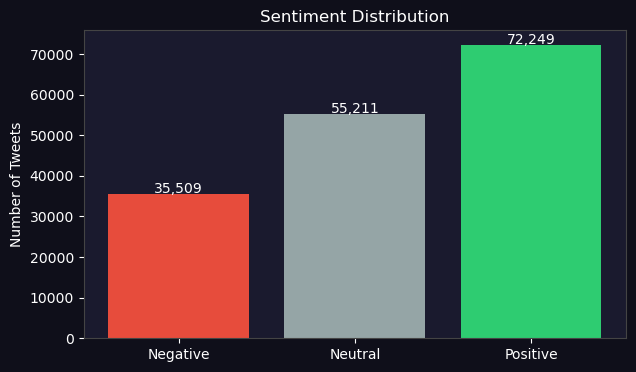

In [57]:
%matplotlib inline
counts = df['sentiment_label'].value_counts().reindex(['Negative', 'Neutral', 'Positive'])

plt.figure(figsize=(7, 4))
plt.bar(counts.index, counts.values, color=['#e74c3c', '#95a5a6', '#2ecc71'])
plt.title('Sentiment Distribution')
plt.ylabel('Number of Tweets')
for i, v in enumerate(counts.values):
    plt.text(i, v + 200, f'{v:,}', ha='center')
plt.show()

#  CHART 1: SENTIMENT DISTRIBUTION

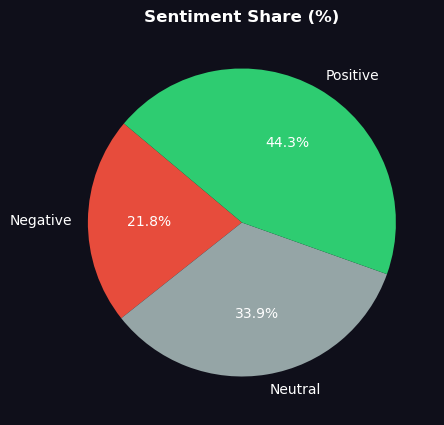

In [61]:
#pie chart
%matplotlib inline
fig, ax = plt.subplots(figsize=(7, 5), facecolor='#0f0f1a')
ax.pie(counts, labels=labels, colors=COLORS, autopct='%1.1f%%', startangle=140,
       textprops={'color': 'white'})
ax.set_title('Sentiment Share (%)', color='white', fontweight='bold')
plt.show()

# CHART 2: SENTIMENT SHARE 

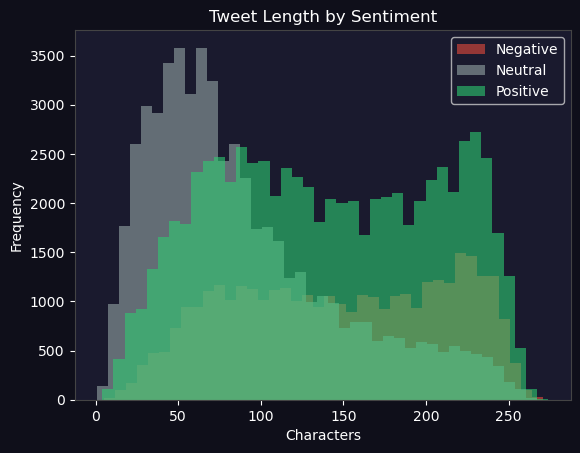

In [62]:
%matplotlib inline
for label, color in zip(['Negative', 'Neutral', 'Positive'], ['#e74c3c', '#95a5a6', '#2ecc71']):
    plt.hist(df[df['sentiment_label'] == label]['tweet_length'],
             bins=40, alpha=0.6, label=label, color=color)
plt.title('Tweet Length by Sentiment')
plt.xlabel('Characters')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# CHART 3: TWEET LENGTH BY SENTIMENT

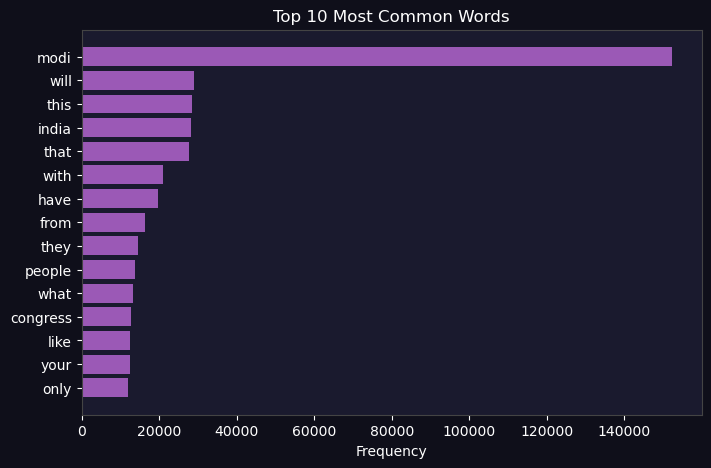

In [63]:
%matplotlib inline
words, freqs = zip(*top_words)
plt.figure(figsize=(8, 5))
plt.barh(words[::-1], freqs[::-1], color='#9b59b6')
plt.title('Top 10 Most Common Words')
plt.xlabel('Frequency')
plt.show()

# CHART 4: TOP 10 MOST COMMON WORDS

In [65]:
# ─────────────────────────────────────────────
#   TASK 4   Sentiment Analysis
# ─────────────────────────────────────────────
print("\n" + "="*60)
print("  TASK 4: SENTIMENT ANALYSIS ")
print("="*60)


  TASK 4: SENTIMENT ANALYSIS 


In [64]:
sample = df.sample(2000, random_state=42).copy()

def analyze(text):
    score = TextBlob(str(text)).sentiment.polarity
    return 'Positive' if score > 0.05 else 'Negative' if score < -0.05 else 'Neutral'

sample['predicted'] = sample['clean_text'].apply(analyze)

accuracy = (sample['predicted'] == sample['sentiment_label']).mean() * 100
print(f"Accuracy: {accuracy:.1f}%")
print("\nPrediction Distribution:\n", sample['predicted'].value_counts())
sample[['clean_text', 'sentiment_label', 'predicted']].head(10)

Accuracy: 94.5%

Prediction Distribution:
 predicted
Positive    801
Neutral     800
Negative    399
Name: count, dtype: int64


,clean_text,sentiment_label,predicted
42229,news flash modi address the nation cancels tri...,Neutral,Neutral
22035,according congress ecosystem bjp divided house...,Positive,Positive
79982,friends did not have the guts let drdo test mo...,Negative,Neutral
118493,did modi violate the model code conduct speaki...,Negative,Negative
12815,raoul gandhy asked modi about nirav for years ...,Neutral,Neutral
146543,its not just modi government people have bough...,Negative,Negative
161797,not talking about chandrababuhe cant challenge...,Neutral,Neutral
136257,taking advantage terrorist attack that ended t...,Negative,Neutral
64783,milestone india successfully shoots down satel...,Positive,Positive
82702,wasn’ nehru’ father’ money not modi’ father’ m...,Positive,Positive
